# Real World Testing of 12 Models

***First We need to find our models and load them***

***The following code prints the paths and structure of the current folder***

In [1]:
import os

import warnings
warnings.filterwarnings('ignore')


def print_tree(directory, indent=""):
    # التأكد من وجود المسار
    if not os.path.exists(directory):
        print("المسار غير موجود!")
        return

    # الحصول على قائمة الملفات والمجلدات
    items = os.listdir(directory)
    
    for i, item in enumerate(sorted(items)):
        # تحديد ما إذا كان هذا هو العنصر الأخير في القائمة لتغيير شكل الخط
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        print(indent + connector + item)
        
        path = os.path.join(directory, item)
        
        # إذا كان العنصر مجلداً، نقوم بالدخول إليه وتكرار العملية (Recursion)
        if os.path.isdir(path):
            new_indent = indent + ("    " if is_last else "│   ")
            print_tree(path, new_indent)

# ضع مسار المجلد الخاص بك هنا (تذكر حرف r قبل المسار)
path = r'C:\Users\grace\junior\Junior Final'
print(os.path.basename(path) + "/")
print_tree(path)


Junior Final/
├── .ipynb_checkpoints
│   ├── DDinter_CatBoost_Binary-checkpoint.ipynb
│   ├── DDinter_CatBoost_Multi-checkpoint.ipynb
│   ├── DDinter_DecisionTree_Binary-checkpoint.ipynb
│   ├── DDinter_DecisionTree_Multi-checkpoint.ipynb
│   ├── DDinter_LogisticRegression_Binary-checkpoint.ipynb
│   ├── DDinter_LogisticRegression_Multi-checkpoint.ipynb
│   ├── DDinter_RandomForest_Binary-checkpoint.ipynb
│   ├── DDinter_RandomForest_Multi-checkpoint.ipynb
│   ├── DDinter_SVM_Binary-checkpoint.ipynb
│   ├── DDinter_SVM_Multi-checkpoint.ipynb
│   ├── DDinter_XGBoost_Binary-checkpoint.ipynb
│   ├── Real_World_Like_testing-checkpoint.ipynb
│   └── preparing full DDinter Dataset-checkpoint.ipynb
├── DDinter_CatBoost_Binary.ipynb
├── DDinter_CatBoost_Multi.ipynb
├── DDinter_DecisionTree_Binary.ipynb
├── DDinter_DecisionTree_Multi.ipynb
├── DDinter_LogisticRegression_Binary.ipynb
├── DDinter_LogisticRegression_Multi.ipynb
├── DDinter_RandomForest_Binary.ipynb
├── DDinter_RandomForest_Multi.i

# Now that We found our models in Saved_models folder we load them

In [2]:
import os
import joblib

MODEL_DIR = "Saved_Models"

models = {}
xgb_encoder = None

for file in os.listdir(MODEL_DIR):
    path = os.path.join(MODEL_DIR, file)

    if file.endswith(".pkl"):
        original_name = file.replace(".pkl", "")

        if file == "xgb_label_encoder.pkl":
            xgb_encoder = joblib.load(path)

        else:
            # Rename models with simple names while storing them
            if original_name == "DDinter_XGBoost_Multi":
                new_name = "XGB_Multi"

            elif original_name == "DDinter_SVM_Multi":
                new_name = "SVM_Multi"

            elif original_name == "DDinter_SVM_Binary":
                new_name = "SVM_Binary"

            elif original_name == "DDinter_RandomForest_Multi":
                new_name = "RF_Multi"

            elif original_name == "DDinter_RandomForest_Binary":
                new_name = "RF_Binary"

            elif original_name == "DDinter_LogisticRegression_Multi":
                new_name = "LogReg_Multi"

            elif original_name == "DDinter_LogisticRegression_Binary":
                new_name = "LogReg_Binary"

            elif original_name == "DDinter_DecisionTree_Multi":
                new_name = "DT_Multi"

            elif original_name == "DDinter_DecisionTree_Binary":
                new_name = "DT_Binary"

            elif original_name == "ddi_CB_pipeline":
                new_name = "CatB_Multi"

            elif original_name == "ddi_binary_xgb_model":
                new_name = "XGB_Binary"

            elif original_name == "ddi_binary_cb_model":
                new_name = "CatB_Binary"

            else:
                new_name = original_name

            models[new_name] = joblib.load(path)

print("Loaded models:")
for k in models.keys():
    print("-", k)

Loaded models:
- DT_Binary
- DT_Multi
- LogReg_Binary
- LogReg_Multi
- RF_Binary
- RF_Multi
- SVM_Binary
- SVM_Multi
- XGB_Multi
- CatB_Binary
- XGB_Binary
- CatB_Multi


**Our models are loaded now we need to create test pairs some from the dataset used for training some from credible sources outside the dataset**

**This will tell us which model is more able to generalise**

**manula drug pairs were verified from credible sources like the Full DDinter dataset pubmed/NIH/BNF and certified doctors**

In [3]:
import pandas as pd

df = pd.read_csv("DDinter_with_negatives.csv")

df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

# 33 samples form dataset
sample_df = df.sample(32, random_state=60)

# 33 manual samples from credible sourses
manual_df = pd.DataFrame({
    "Drug_A": [
        "acetylsalicylic acid","warfarin","clopidogrel","heparin","metformin","simvastatin","sertraline","amiodarone",
        "metformin","lisinopril","digoxin","atorvastatin","fluoxetine","carbamazepine","warfarin",
        "metformin","ibuprofen","Acetaminophen","amlodipine",
        "metformin","amoxicillin","insulin","atorvastatin",
        "metformin","sertraline","metformin","Vandetanib","ibuprofen","Citalopram","Fludrocortisone","Promethazine","ibuprofen","Amlodipine"
    ],
    "Drug_B": [
        "ibuprofen","acetylsalicylic acid","acetylsalicylic acid","acetylsalicylic acid","iodinated contrast","clarithromycin","linezolid","fluconazole",
        "furosemide","spironolactone","verapamil","amlodipine","tramadol","oral contraceptives","amiodarone",
        "omeprazole","lisinopril","warfarin","simvastatin",
        "cetirizine","Acetaminophen","loratadine","azithromycin",
        "gabapentin","vitamin d","Acetaminophen","Omeprazole","Acetaminophen","Fosphenytoin","Fosphenytoin","Folic acid","Acetaminophen","Rosuvastatin"
    ],
    "Level": [
        "Major","Major","Major","Major","Major","Major","Major","Major",
        "Moderate","Major","Moderate","Moderate","Major","Moderate","Major",
        "Unknown","Moderate","Moderate","Major",
        "No Interaction","No Interaction","No Interaction","Moderate",
        "Unknown","Unknown","No Interaction","Minor", "Unknown","Moderate","Moderate","Unknown","Unknown","No Interaction"
    ]
})

test_df = pd.concat([sample_df, manual_df], ignore_index=True)

X_test = test_df[['Drug_A', 'Drug_B']]
y_true = test_df['Level']

In [4]:
manual_df.head(33)

,Drug_A,Drug_B,Level
0,acetylsalicylic acid,ibuprofen,Major
1,warfarin,acetylsalicylic acid,Major
2,clopidogrel,acetylsalicylic acid,Major
3,heparin,acetylsalicylic acid,Major
4,metformin,iodinated contrast,Major
5,simvastatin,clarithromycin,Major
6,sertraline,linezolid,Major
7,amiodarone,fluconazole,Major
8,metformin,furosemide,Moderate
9,lisinopril,spironolactone,Major


**let's verify if the new pairs exist in the dataset first**

In [5]:
# Create canonical pair representation (order-independent)
df['pair'] = df.apply(lambda x: tuple(sorted([x['Drug_A'], x['Drug_B']])), axis=1)

# Build set of existing pairs for fast lookup
existing_pairs = set(df['pair'])

# Apply same transformation to manual dataset
manual_df['pair'] = manual_df.apply(lambda x: tuple(sorted([x['Drug_A'], x['Drug_B']])), axis=1)

# Check overlaps
manual_df['exists_in_dataset'] = manual_df['pair'].apply(lambda x: x in existing_pairs)

# Show results
print("\n🔍 Overlap check:")
print(manual_df[['Drug_A', 'Drug_B', 'Level', 'exists_in_dataset']])

# Summary
print("\n📊 Summary:")
print("Already existing pairs:", manual_df['exists_in_dataset'].sum())
print("New unique pairs:", (~manual_df['exists_in_dataset']).sum())


🔍 Overlap check:
                  Drug_A                Drug_B           Level  \
0   acetylsalicylic acid             ibuprofen           Major   
1               warfarin  acetylsalicylic acid           Major   
2            clopidogrel  acetylsalicylic acid           Major   
3                heparin  acetylsalicylic acid           Major   
4              metformin    iodinated contrast           Major   
5            simvastatin        clarithromycin           Major   
6             sertraline             linezolid           Major   
7             amiodarone           fluconazole           Major   
8              metformin            furosemide        Moderate   
9             lisinopril        spironolactone           Major   
10               digoxin             verapamil        Moderate   
11          atorvastatin            amlodipine        Moderate   
12            fluoxetine              tramadol           Major   
13         carbamazepine   oral contraceptives        Mode

**No manual pairs exist in the dataset**

**Now we create a prediction function for all models**

# We need some helper functions first

In [6]:
import numpy as np
import time
import pandas as pd
from typing import Dict, Any, Optional, List, Tuple
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [7]:
def get_model_type(model_name: str) -> str:
    """Determine if the model is binary or multiclass based on its name."""
    return "multiclass" if "multi" in model_name.lower() else "binary"


def decode_prediction(pred: Any, model_name: str, model_type: str, 
                      encoder: Optional[LabelEncoder] = None) -> str:
    """Decode raw model prediction into human-readable label."""
    
    # Handle multiclass XGBoost/CatBoost with encoder
    if model_type == "multiclass" and encoder is not None and (
        "xgb" in model_name.lower() or "cat" in model_name.lower()
    ):
        try:
            pred_label = encoder.inverse_transform([int(pred)])[0]
        except (ValueError, TypeError):
            pred_label = pred
    else:
        pred_label = pred

    pred_label = str(pred_label).strip()

    # Normalize binary predictions
    if model_type == "binary":
        if pred_label.lower() in ["1", "interaction", "yes"]:
            return "Interaction"
        elif pred_label.lower() in ["0", "no interaction", "no"]:
            return "No Interaction"

    return pred_label


def is_prediction_correct(pred_label: str, true_label: Any, model_type: str) -> bool:
    """Determine if prediction is correct based on model type."""
    
    if true_label is None:
        return False

    pred_lower = str(pred_label).strip().lower()
    true_lower = str(true_label).strip().lower()

    if model_type == "binary":
        if pred_lower == "interaction":
            return true_lower in ["major", "moderate", "minor", "unknown", "interaction"]
        elif pred_lower == "no interaction":
            return true_lower in ["no interaction", "none", "no"]
        return False
    else:
        # Multiclass: exact match (case insensitive)
        return pred_lower == true_lower


def get_confidence(model, X_row: pd.DataFrame) -> float:
    """Extract prediction confidence if model supports probability outputs."""
    if hasattr(model, "predict_proba"):
        try:
            prob = model.predict_proba(X_row)
            return float(np.max(prob, axis=1)[0])
        except Exception:
            return np.nan
    return np.nan

# Main prediction function

In [8]:
def predict_model(
    model_name: str,
    model: Any,
    X_row: pd.DataFrame,
    true_label: Optional[Any] = None,
    xgb_encoder: Optional[LabelEncoder] = None
) -> Dict[str, Any]:
    """
    Predict drug interaction using a given model and return detailed results.
    """
    start_time = time.time()

    drug_a = X_row.iloc[0]["Drug_A"]
    drug_b = X_row.iloc[0]["Drug_B"]

    model_type = get_model_type(model_name)

    # Make prediction
    raw_pred = model.predict(X_row)[0]

    # Decode prediction
    pred_label = decode_prediction(raw_pred, model_name, model_type, xgb_encoder)

    # Get confidence
    confidence = get_confidence(model, X_row)

    # Calculate inference time
    inference_time = time.time() - start_time

    # Determine correctness
    correct = is_prediction_correct(pred_label, true_label, model_type)

    return {
        "Drug_Pair": f"{drug_a} + {drug_b}",
        "Model_Name": model_name,
        "Model_Type": model_type,
        "Prediction": pred_label,
        "True_Label": str(true_label) if true_label is not None else None,
        "Correct": correct,
        "Confidence": round(confidence, 4) if not np.isnan(confidence) else None,
        "Inference_Time": round(inference_time, 6)
    }


# Evaluation Function

In [9]:
def evaluate_models(
    predictions: List[Dict[str, Any]],
    model_type: str = "binary"
) -> Dict[str, Any]:
    """
    Calculate classification metrics (Precision, Recall, F1, Accuracy) from list of predictions.
    """
    if not predictions:
        return {"error": "No predictions provided"}

    y_true = []
    y_pred = []

    for pred in predictions:
        true_label = pred.get("True_Label")
        pred_label = pred.get("Prediction")

        if true_label is None:
            continue

        # Normalize labels for consistent metric calculation
        if model_type == "binary":
            y_true.append(1 if str(true_label).strip().lower() in 
                         ["major", "moderate", "minor", "unknown", "interaction"] else 0)
            y_pred.append(1 if str(pred_label).strip().lower() == "interaction" else 0)
        else:
            # Multiclass: use string labels directly
            y_true.append(str(true_label).strip().lower())
            y_pred.append(str(pred_label).strip().lower())

    if not y_true:
        return {"error": "No valid true labels found"}

    # Calculate metrics
    if model_type == "binary":
        average = "binary"
    else:
        average = "weighted"  # or 'macro' depending on your preference

    metrics = {
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average=average, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, average=average, zero_division=0), 4),
        "F1_Score": round(f1_score(y_true, y_pred, average=average, zero_division=0), 4),
        "Support": len(y_true)
    }

    return metrics

**Now we run all models and save their results**

In [10]:
import warnings
import pandas as pd

warnings.filterwarnings('ignore')

# ===================== MODEL EVALUATION LOOP =====================

results = []

print("Starting model evaluation...\n")

for model_name, model in models.items():
    print(f"Running: {model_name}")
    
    for i in range(len(X_test)):
        row = X_test.iloc[[i]]                    # Keep as DataFrame for compatibility
        true_label = y_true.iloc[i]

        # ===================== PREDICT =====================
        output = predict_model(
            model_name=model_name,
            model=model,
            X_row=row,
            true_label=true_label,
            xgb_encoder=xgb_encoder if 'xgb_encoder' in globals() else None   # Pass encoder if available
        )

        # Add sample identifier
        output["Sample_ID"] = i

        results.append(output)

print("\nEvaluation completed for all models.\n")

# ===================== CREATE RESULTS DATAFRAME =====================

results_df = pd.DataFrame(results)

# ===================== REORDER COLUMNS =====================

desired_columns = [
    "Sample_ID",
    "Drug_Pair",
    "Model_Name",
    "Model_Type",
    "Prediction",
    "True_Label",
    "Correct",
    "Confidence",
    "Inference_Time"
]

# Only include columns that exist (in case some are missing)
results_df = results_df[[col for col in desired_columns if col in results_df.columns]]

# ===================== PREVIEW =====================
print("Results Preview:")
print(results_df.head())

print(f"\nTotal predictions made: {len(results_df)}")

Starting model evaluation...

Running: DT_Binary
Running: DT_Multi
Running: LogReg_Binary
Running: LogReg_Multi
Running: RF_Binary
Running: RF_Multi
Running: SVM_Binary
Running: SVM_Multi
Running: XGB_Multi
Running: CatB_Binary
Running: XGB_Binary
Running: CatB_Multi

Evaluation completed for all models.

Results Preview:
   Sample_ID                  Drug_Pair Model_Name Model_Type      Prediction  \
0          0  gadobenic acid + pindolol  DT_Binary     binary  No Interaction   
1          1   diazoxide + pioglitazone  DT_Binary     binary     Interaction   
2          2       atropine + iopamidol  DT_Binary     binary     Interaction   
3          3    bosutinib + roflumilast  DT_Binary     binary  No Interaction   
4          4      deflazacort + quinine  DT_Binary     binary  No Interaction   

       True_Label  Correct  Confidence  Inference_Time  
0        Moderate    False      0.6560        0.010274  
1        Moderate     True      0.9795        0.009579  
2         Unknown 

In [11]:
# ===================== PERFORMANCE SUMMARY =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

summary_data = []

for model_name in results_df['Model_Name'].unique():
    model_results = results_df[results_df['Model_Name'] == model_name]
    
    # Determine model type from first row
    model_type = model_results.iloc[0]['Model_Type']
    
    metrics = evaluate_models(model_results.to_dict('records'), model_type=model_type)
    
    summary_data.append({
        "Model_Name": model_name,
        "Model_Type": model_type,
        "Accuracy": metrics.get("Accuracy"),
        "Precision": metrics.get("Precision"),
        "Recall": metrics.get("Recall"),
        "F1_Score": metrics.get("F1_Score"),
        "Support": metrics.get("Support"),
        "Avg_Inference_Time": round(model_results["Inference_Time"].mean(), 6)
    })

summary_df = pd.DataFrame(summary_data)

# Sort by F1-Score descending
summary_df = summary_df.sort_values(by="F1_Score", ascending=False)

print(summary_df.round(4))


MODEL PERFORMANCE SUMMARY
       Model_Name  Model_Type  Accuracy  Precision  Recall  F1_Score  Support  \
2   LogReg_Binary      binary    0.8154     0.9429  0.7674    0.8462       65   
6      SVM_Binary      binary    0.8154     0.9429  0.7674    0.8462       65   
4       RF_Binary      binary    0.6923     1.0000  0.5349    0.6970       65   
0       DT_Binary      binary    0.6769     1.0000  0.5116    0.6769       65   
9     CatB_Binary      binary    0.6615     0.9565  0.5116    0.6667       65   
10     XGB_Binary      binary    0.6615     1.0000  0.4884    0.6562       65   
7       SVM_Multi  multiclass    0.5538     0.5758  0.5538    0.5377       65   
5        RF_Multi  multiclass    0.5692     0.6953  0.5692    0.5365       65   
8       XGB_Multi  multiclass    0.5692     0.6962  0.5692    0.5358       65   
3    LogReg_Multi  multiclass    0.5231     0.5268  0.5231    0.4838       65   
1        DT_Multi  multiclass    0.5077     0.5536  0.5077    0.4777       65   
1

In [12]:
# ===================== SIMPLE & CLEAR COMPARISON TABLE =====================
# Shows only Predictions vs True Label (No Correctness columns)

# Select relevant columns
comparison_long = results_df[['Sample_ID', 'Drug_Pair', 'True_Label', 
                              'Model_Name', 'Prediction']]

# Pivot so each model has its own prediction column
comparison_table = comparison_long.pivot(
    index=['Sample_ID', 'Drug_Pair', 'True_Label'],
    columns='Model_Name',
    values='Prediction'
).reset_index()

# Rename columns for clarity (optional but recommended)
comparison_table.columns.name = None  # Remove the 'Model_Name' label

# Optional: Reorder columns for better readability
id_cols = ['Sample_ID', 'Drug_Pair', 'True_Label']
model_cols = [col for col in comparison_table.columns if col not in id_cols]

final_columns = id_cols + sorted(model_cols)   # Sort model names alphabetically
comparison_table = comparison_table[final_columns]


# ===================== SAVE =====================
comparison_table.to_csv("model_predictions_comparison.csv", index=False)
print("\nComparison table saved as 'model_predictions_comparison.csv'")

# ===================== DISPLAY =====================
print("\n=== MODEL PREDICTIONS vs TRUE LABEL COMPARISON TABLE ===")
print("=" * 90)
comparison_table.head(66)  # Show first 10 rows


Comparison table saved as 'model_predictions_comparison.csv'

=== MODEL PREDICTIONS vs TRUE LABEL COMPARISON TABLE ===


,Sample_ID,Drug_Pair,True_Label,CatB_Binary,CatB_Multi,DT_Binary,DT_Multi,LogReg_Binary,LogReg_Multi,RF_Binary,RF_Multi,SVM_Binary,SVM_Multi,XGB_Binary,XGB_Multi
0,0,gadobenic acid + pindolol,Moderate,No Interaction,Moderate,No Interaction,Moderate,Interaction,Moderate,No Interaction,Moderate,Interaction,Moderate,No Interaction,Moderate
1,1,diazoxide + pioglitazone,Moderate,Interaction,Moderate,Interaction,Moderate,Interaction,Moderate,Interaction,Moderate,Interaction,Moderate,Interaction,Moderate
2,2,atropine + iopamidol,Unknown,Interaction,Unknown,Interaction,Major,Interaction,Major,Interaction,Unknown,Interaction,Major,Interaction,Unknown
3,3,bosutinib + roflumilast,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction
4,4,deflazacort + quinine,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,60,Citalopram + Fosphenytoin,Moderate,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction
61,61,Fludrocortisone + Fosphenytoin,Moderate,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction
62,62,Promethazine + Folic acid,Unknown,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction,No Interaction
63,63,ibuprofen + Acetaminophen,Unknown,No Interaction,No Interaction,No Interaction,No Interaction,Interaction,Major,No Interaction,No Interaction,Interaction,Major,No Interaction,No Interaction


**form the tabel we notice logistic regression and svm are more effective with noisy data. example generic names of drugs**

**We notice although boosting algorithms showed better performance on the original train/test data, when put in real life consitions random forest, and logistic regression and svm out performed them**

**The model we will choose for our suystem is binary logistic regression**

# Additional plots

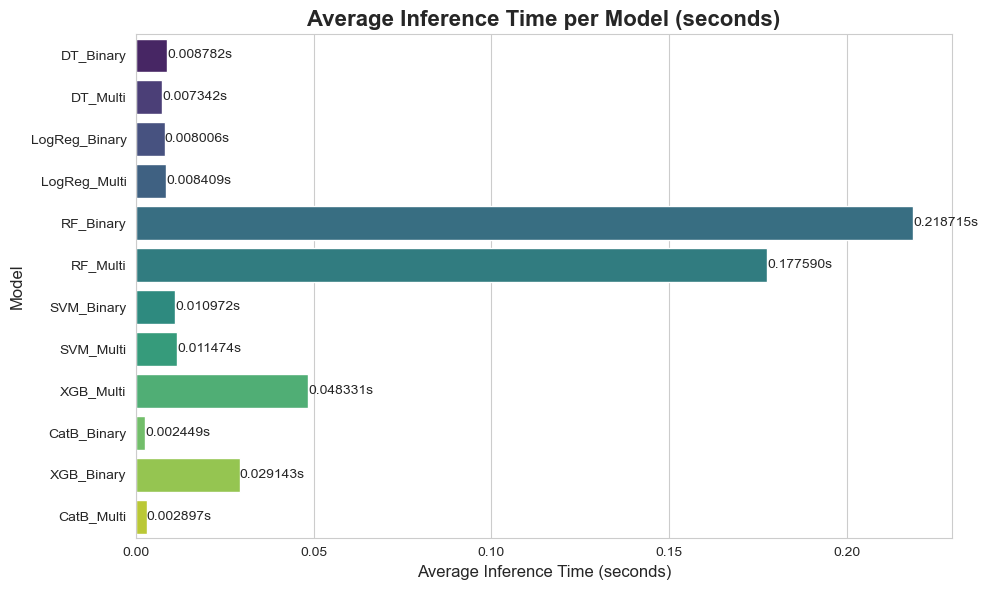

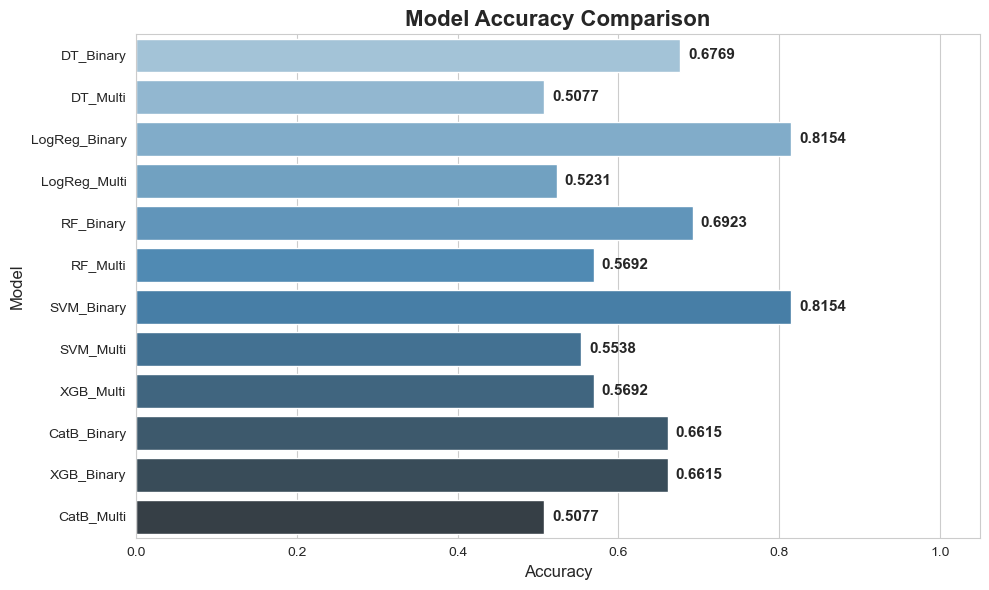

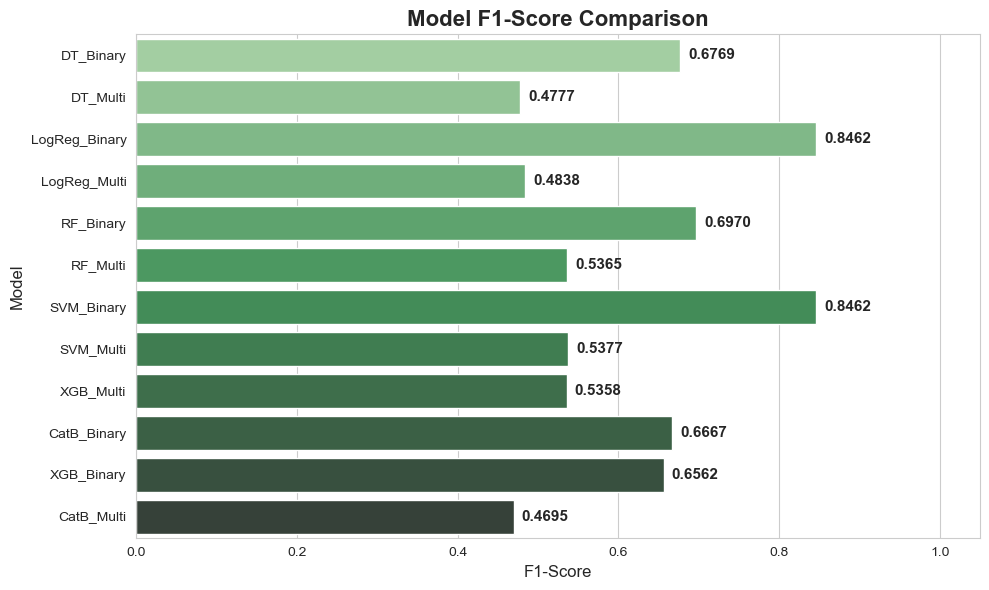

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ===================== PREPARE SUMMARY DATA =====================
# (Make sure you have already run the summary_df from previous code)

# If you haven't created summary_df yet, run this block first:
summary_data = []

for model_name in results_df['Model_Name'].unique():
    model_results = results_df[results_df['Model_Name'] == model_name]
    model_type = model_results.iloc[0]['Model_Type']
    
    metrics = evaluate_models(model_results.to_dict('records'), model_type=model_type)
    
    summary_data.append({
        "Model": model_name,
        "Model_Type": model_type,
        "Accuracy": metrics.get("Accuracy", 0),
        "F1_Score": metrics.get("F1_Score", 0),
        "Precision": metrics.get("Precision", 0),
        "Recall": metrics.get("Recall", 0),
        "Avg_Inference_Time": model_results["Inference_Time"].mean()
    })

summary_df = pd.DataFrame(summary_data)

# ===================== 1. INFERENCE TIME COMPARISON =====================
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x='Avg_Inference_Time', y='Model', data=summary_df, palette='viridis')

plt.title('Average Inference Time per Model (seconds)', fontsize=16, fontweight='bold')
plt.xlabel('Average Inference Time (seconds)', fontsize=12)
plt.ylabel('Model', fontsize=12)

# Add value labels on bars
for i, v in enumerate(summary_df['Avg_Inference_Time']):
    ax1.text(v + 0.00001, i, f'{v:.6f}s', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# ===================== 2. ACCURACY COMPARISON =====================
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='Blues_d')

plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.05)

for i, v in enumerate(summary_df['Accuracy']):
    ax2.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ===================== 3. F1-SCORE COMPARISON =====================
plt.figure(figsize=(10, 6))
ax3 = sns.barplot(x='F1_Score', y='Model', data=summary_df, palette='Greens_d')

plt.title('Model F1-Score Comparison', fontsize=16, fontweight='bold')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.05)

for i, v in enumerate(summary_df['F1_Score']):
    ax3.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

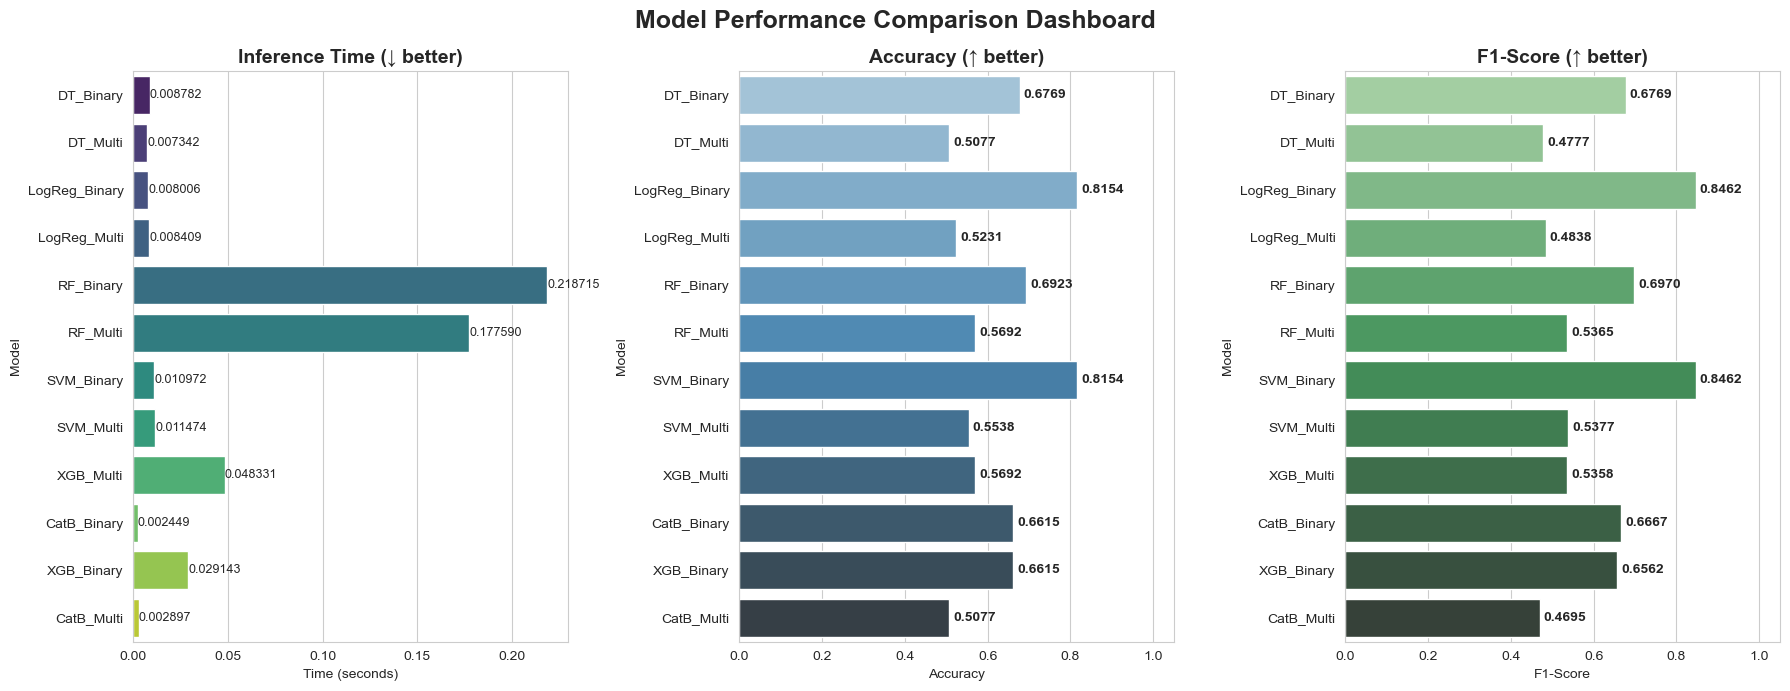

In [14]:
# ===================== COMBINED COMPARISON DASHBOARD =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Inference Time
sns.barplot(x='Avg_Inference_Time', y='Model', data=summary_df, ax=axes[0], palette='viridis')
axes[0].set_title('Inference Time (↓ better)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time (seconds)')

# Accuracy
sns.barplot(x='Accuracy', y='Model', data=summary_df, ax=axes[1], palette='Blues_d')
axes[1].set_title('Accuracy (↑ better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1.05)

# F1-Score
sns.barplot(x='F1_Score', y='Model', data=summary_df, ax=axes[2], palette='Greens_d')
axes[2].set_title('F1-Score (↑ better)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('F1-Score')
axes[2].set_xlim(0, 1.05)

# Add value labels
for ax, metric in zip(axes, ['Avg_Inference_Time', 'Accuracy', 'F1_Score']):
    for i, v in enumerate(summary_df[metric]):
        if metric == 'Avg_Inference_Time':
            ax.text(v + 0.000005, i, f'{v:.6f}', va='center', fontsize=9)
        else:
            ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison Dashboard', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()